# Formação de Pares — Método da Distância (Gatev et al., 2006)

Implementa a **fase de formação** do método de distância.

As janelas são definidas em **meses calendário**, com os mesmos parâmetros do método da cointegração (`MESES_FORMACAO`, `MESES_NEGOCIACAO`, `PASSO_MESES`) — assim os dois métodos podem ser comparados janela a janela.

Para cada janela rolante de formação:
1. Filtra ativos com dados **completos** no período
2. Normaliza preços: `Q_i(t) = P_i(t) / P_i(0)` — todos partem de 1
3. Mede a **distância SSD** entre todos os pares: `D(i,j) = Σ (Q_i(t) - Q_j(t))²`
4. Seleciona os **top-20 pares** de menor distância
5. Salva a **média e desvio** do spread para uso na fase de negociação

In [11]:
import re
import pandas as pd
import numpy as np

# ── Janela rolante ────────────────────────────────────────────────────────────
# Mesmos parâmetros do método da cointegração (pairs_formation_coint.ipynb) para
# que as duas metodologias sejam comparáveis janela a janela.
MESES_FORMACAO   = 12  # duração do período de formação (meses)
MESES_NEGOCIACAO = 6   # duração do período de negociação (meses)
PASSO_MESES      = 1   # avanço da janela a cada iteração
                       #   6 → semestral, ~69 janelas (ritmo original de Gatev et al.)
                       #   1 → mensal, ~400 janelas (= Rad et al.)

# ── Seleção de pares ──────────────────────────────────────────────────────────
TOP_K   = 20    # pares selecionados por janela
SSD_MIN = 0.01  # SSD mínimo aceito
                # Ghost tickers (preços idênticos) têm SSD ≈ 0
                # Pares reais têm SSD ~ 0.05–0.5

# Colunas de metadados
META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 1. Carregando os dados

In [12]:
#df = pd.read_csv('../../data_bases/base_completa.csv', parse_dates=['date'])
df = pd.read_csv('../../data_bases/base_unificada.csv', parse_dates=['date'])
df = df.set_index('date')

n_ativos = df.shape[1] - len(META_COLS)
print(f"Dias de pregão: {df.shape[0]}")
print(f"Ativos no universo total: {n_ativos}")
print(f"Período: {df.index[0].date()} até {df.index[-1].date()}")

KeyboardInterrupt: 

In [ ]:
df

,year,semester,period,day_in_semester,total_days_sem,UN,1005945D,162007Q,RDPL,BGG,...,WELL,WLTW,WRB,WRK,WSM,WST,WTW,WYND,XYZ,ZBRA
date,,,,,,,,,,,,,,,,,,,,,
1990-07-03,1990,2,1990/S2,1,127,3.3082,11.7377,32.6951,10.2566,3.6022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-07-05,1990,2,1990/S2,2,127,3.3321,11.8106,32.1859,10.2396,3.5747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-07-06,1990,2,1990/S2,3,127,3.2699,11.5919,30.7599,10.1207,3.4922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-07-09,1990,2,1990/S2,4,127,3.3082,11.6648,32.0840,10.1886,3.4647,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-07-10,1990,2,1990/S2,5,127,3.2986,11.6648,31.6766,10.2226,3.4510,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,2025,2,2025/S2,124,128,NaN,NaN,NaN,NaN,NaN,...,187.036377,NaN,70.550560,NaN,188.124954,276.198822,332.492004,NaN,66.050003,245.899994
2025-12-26,2025,2,2025/S2,125,128,NaN,NaN,NaN,NaN,NaN,...,187.195816,NaN,70.480644,NaN,187.251205,273.842712,332.571533,NaN,66.269997,246.270004
2025-12-29,2025,2,2025/S2,126,128,NaN,NaN,NaN,NaN,NaN,...,188.969513,NaN,70.700371,NaN,185.811493,275.140564,332.124268,NaN,65.919998,245.740005


## 2. Construindo as janelas temporais

As janelas são definidas em **meses calendário**, o que permite `PASSO_MESES = 1` (mensal, como Rad et al.) ou `PASSO_MESES = 6` (semestral, o ritmo original de Gatev et al.).

In [ ]:
# Índice de mês para cada dia de pregão — calculado uma vez para uso no loop
meses_por_linha = pd.PeriodIndex(df.index, freq='M')
meses_unicos    = sorted(meses_por_linha.unique())

n_janelas = max(0, (len(meses_unicos) - MESES_FORMACAO - MESES_NEGOCIACAO) // PASSO_MESES + 1)

print(f"Meses disponíveis: {len(meses_unicos)}")
print(f"Primeiro: {meses_unicos[0]} | Último: {meses_unicos[-1]}")
print(f"Janelas a processar: {n_janelas}")
print()

ex_form = meses_unicos[:MESES_FORMACAO]
ex_neg  = meses_unicos[MESES_FORMACAO : MESES_FORMACAO + MESES_NEGOCIACAO]
print("Exemplo — 1ª janela:")
print(f"  Formação:   {ex_form[0]} → {ex_form[-1]}")
print(f"  Negociação: {ex_neg[0]} → {ex_neg[-1]}")

Meses disponíveis: 426
Primeiro: 1990-07 | Último: 2025-12
Janelas a processar: 409

Exemplo — 1ª janela:
  Formação:   1990-07 → 1991-06
  Negociação: 1991-07 → 1991-12


## 3. Funções do método de distância

In [ ]:
def filtrar_ativos_completos(precos):
    """Remove ativos com qualquer dado faltante no período."""
    return precos.dropna(axis=1, how='any')


def normalizar_precos(precos):
    """Q_i(t) = P_i(t) / P_i(0): todos os ativos partem de 1."""
    return precos.div(precos.iloc[0])

# 1>1.05>1.03>2.0>1.5
# 100>105>103>200>150
# 1>1.05>1.03>2.0>1.5 verificar 
def calcular_ssd(Q):
    """
    Distância SSD entre todos os pares:
      D(i,j) = Σ_t (Q_i(t) - Q_j(t))²
             = ||q_i||² + ||q_j||² - 2·<q_i, q_j>

    Retorna DataFrame simétrico (n x n).
    """
    arr   = Q.values
    G     = arr.T @ arr
    norms = np.diag(G)
    ssd   = norms[:, None] + norms[None, :] - 2 * G
    return pd.DataFrame(ssd, index=Q.columns, columns=Q.columns)


def mesmo_emissor(ticker1, ticker2):
    """
    Retorna True se os dois tickers são classes do mesmo emissor.
    Ex: GOOGL/GOOG, FOXA/FOX, BRK_A/BRK_B, UAA/UA, DISCA/DISCK.
    """
    def base(t):
        t = re.sub(r'[._][A-Z]$', '', t)
        if len(t) > 2 and t[-1] in 'ABCKL':
            t = t[:-1]
        return t

    return base(ticker1) == base(ticker2)


def selecionar_top_pares(ssd_df, top_k, ssd_min=SSD_MIN):
    """
    Retorna os top_k pares com menor SSD (cada par uma única vez).

    Dois filtros aplicados antes de ranquear:
    1. Mesmo emissor   — ex: GOOGL/GOOG, FOXA/FOX
    2. SSD < ssd_min   — ghost tickers com preços quase idênticos
                         (tickers Bloomberg de empresas extintas têm SSD ≈ 0)
    """
    arr     = ssd_df.values
    tickers = ssd_df.columns.tolist()

    i_idx, j_idx = np.triu_indices(len(tickers), k=1)
    ssds = arr[i_idx, j_idx]

    validos = np.array([
        k for k in range(len(i_idx))
        if not mesmo_emissor(tickers[i_idx[k]], tickers[j_idx[k]])
        and ssds[k] >= ssd_min
    ])
    i_idx = i_idx[validos]
    j_idx = j_idx[validos]
    ssds  = ssds[validos]

    n_pares = min(top_k, len(ssds))
    top_idx = np.argsort(ssds)[:n_pares]

    return pd.DataFrame({
        'ativo1': [tickers[i_idx[k]] for k in top_idx],
        'ativo2': [tickers[j_idx[k]] for k in top_idx],
        'ssd':    [ssds[k] for k in top_idx],
    })


def calcular_spread_stats(Q, ativo1, ativo2):
    """Média e desvio padrão do spread no período de formação."""
    spread = Q[ativo1] - Q[ativo2]
    return spread.mean(), spread.std()

## 4. Processando todas as janelas de formação

Para cada janela:
- `meses_form`: os `MESES_FORMACAO` meses onde os pares são selecionados
- `meses_neg`: os `MESES_NEGOCIACAO` meses seguintes — onde os pares serão negociados

A janela avança `PASSO_MESES` meses por iteração. Com `PASSO_MESES = 1` os períodos de negociação se sobrepõem (até `MESES_NEGOCIACAO` carteiras ativas em paralelo), exatamente como no método da cointegração.

In [ ]:
resultados = []
colunas_preco = [c for c in df.columns if c not in META_COLS]

fim = len(meses_unicos) - MESES_FORMACAO - MESES_NEGOCIACAO + 1

for i in range(0, fim, PASSO_MESES):

    # Define a janela em meses calendário
    meses_form = meses_unicos[i : i + MESES_FORMACAO]
    meses_neg  = meses_unicos[i + MESES_FORMACAO : i + MESES_FORMACAO + MESES_NEGOCIACAO]

    form_inicio = str(meses_form[0])
    form_fim    = str(meses_form[-1])
    neg_inicio  = str(meses_neg[0])
    neg_fim     = str(meses_neg[-1])
    janela_id   = f"{form_inicio}_a_{form_fim}"

    # Recorta os dados do período de formação
    mask = meses_por_linha.isin(meses_form)
    precos_raw = df.loc[mask, colunas_preco]

    # Mantém só ativos com dados completos no período
    precos = filtrar_ativos_completos(precos_raw)

    if precos.shape[1] < 2:
        print(f"{janela_id}: sem ativos suficientes, pulando.")
        continue

    # Normaliza, calcula distâncias e seleciona pares
    Q         = normalizar_precos(precos)
    ssd_df    = calcular_ssd(Q)
    top_pares = selecionar_top_pares(ssd_df, TOP_K)

    # Calcula estatísticas do spread para cada par selecionado
    for rank, row in top_pares.iterrows():
        media, desvio = calcular_spread_stats(Q, row['ativo1'], row['ativo2'])
        resultados.append({
            'janela':            janela_id,
            'formacao_inicio':   form_inicio,
            'formacao_fim':      form_fim,
            'negociacao_inicio': neg_inicio,
            'negociacao_fim':    neg_fim,
            'rank':              rank + 1,
            'ativo1':            row['ativo1'],
            'ativo2':            row['ativo2'],
            'ssd':               row['ssd'],
            'spread_media':      media,
            'spread_desvio':     desvio,
        })

    print(f"{janela_id}: {precos.shape[1]:4d} ativos — negociação {neg_inicio} → {neg_fim}")

1990-07_a_1991-06:  690 ativos — negociação 1991-07 → 1991-12
1990-08_a_1991-07:  691 ativos — negociação 1991-08 → 1992-01
1990-09_a_1991-08:  690 ativos — negociação 1991-09 → 1992-02
1990-10_a_1991-09:  690 ativos — negociação 1991-10 → 1992-03
1990-11_a_1991-10:  690 ativos — negociação 1991-11 → 1992-04
1990-12_a_1991-11:  689 ativos — negociação 1991-12 → 1992-05
1991-01_a_1991-12:  690 ativos — negociação 1992-01 → 1992-06
1991-02_a_1992-01:  691 ativos — negociação 1992-02 → 1992-07
1991-03_a_1992-02:  692 ativos — negociação 1992-03 → 1992-08
1991-04_a_1992-03:  695 ativos — negociação 1992-04 → 1992-09
1991-05_a_1992-04:  699 ativos — negociação 1992-05 → 1992-10
1991-06_a_1992-05:  702 ativos — negociação 1992-06 → 1992-11
1991-07_a_1992-06:  704 ativos — negociação 1992-07 → 1992-12
1991-08_a_1992-07:  707 ativos — negociação 1992-08 → 1993-01
1991-09_a_1992-08:  708 ativos — negociação 1992-09 → 1993-02
1991-10_a_1992-09:  709 ativos — negociação 1992-10 → 1993-03
1991-11_

## 5. Resultados

Com o filtro `SSD_MIN`, ghost tickers são eliminados na seleção — o número de pares por janela pode ser ligeiramente menor que `TOP_K` nas janelas mais antigas, onde o universo válido é menor.

In [ ]:
pares_df = pd.DataFrame(resultados)

print(f"Janelas processadas:  {pares_df['janela'].nunique()}")
print(f"Pares registrados:    {len(pares_df)}")
print(f"Pares por janela:     {len(pares_df) / pares_df['janela'].nunique():.1f}")

pares_df.head(10)

Janelas processadas:  409
Pares registrados:    8180
Pares por janela:     20.0


,janela,formacao_inicio,formacao_fim,negociacao_inicio,negociacao_fim,rank,ativo1,ativo2,ssd,spread_media,spread_desvio
0,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,1,GPUI,FPC,0.080954,0.003058,0.017732
1,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,2,FPC,ES,0.097991,0.006922,0.018544
2,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,3,45200Q,CNP,0.101924,-0.000622,0.020182
3,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,4,SCG,WEC,0.103967,-0.003869,0.020021
4,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,5,PEG,0961514D,0.104052,-0.011144,0.017074
5,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,6,PEG,PPL,0.111581,-0.002759,0.020945
6,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,7,D,ES,0.116763,0.009023,0.019629
7,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,8,EIX,PPL,0.133447,0.004822,0.022593
8,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,9,CNP,SO,0.138564,0.009598,0.021489
9,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,10,GPUI,ES,0.140547,0.009980,0.021499


In [ ]:
pares_df.to_csv('output/pares_formados.csv', index=False)
print("Pares salvos em: output/pares_formados.csv")

Pares salvos em: output/pares_formados.csv


## 6. Exemplo: pares da primeira janela

Confere os pares selecionados e as estatísticas do spread.

In [ ]:
primeira_janela = pares_df['janela'].iloc[0]
display(
    pares_df[pares_df['janela'] == primeira_janela]
    .reset_index(drop=True)
)

,janela,formacao_inicio,formacao_fim,negociacao_inicio,negociacao_fim,rank,ativo1,ativo2,ssd,spread_media,spread_desvio
0,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,1,GPUI,FPC,0.080954,0.003058,0.017732
1,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,2,FPC,ES,0.097991,0.006922,0.018544
2,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,3,45200Q,CNP,0.101924,-0.000622,0.020182
3,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,4,SCG,WEC,0.103967,-0.003869,0.020021
4,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,5,PEG,0961514D,0.104052,-0.011144,0.017074
5,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,6,PEG,PPL,0.111581,-0.002759,0.020945
6,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,7,D,ES,0.116763,0.009023,0.019629
7,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,8,EIX,PPL,0.133447,0.004822,0.022593
8,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,9,CNP,SO,0.138564,0.009598,0.021489
9,1990-07_a_1991-06,1990-07,1991-06,1991-07,1991-12,10,GPUI,ES,0.140547,0.009980,0.021499


---
## 7. Visualização: trajetórias normalizadas dos pares selecionados

Para 3 janelas representativas — pré-crise financeira (formação até 2008-06), COVID (até 2020-06) e recente (até 2024-06) — mostramos os **top-3 pares** de cada janela (excluindo SSD ≈ 0, que são classes distintas da mesma empresa).

Cada bloco de 2 linhas mostra:
- **Linha de cima**: trajetórias $Q_i(t)$ e $Q_j(t)$ normalizadas — partem de 1 e co-movem ao longo da formação
- **Linha de baixo**: spread $Q_i(t) - Q_j(t)$ com banda $\mu \pm 2\sigma$

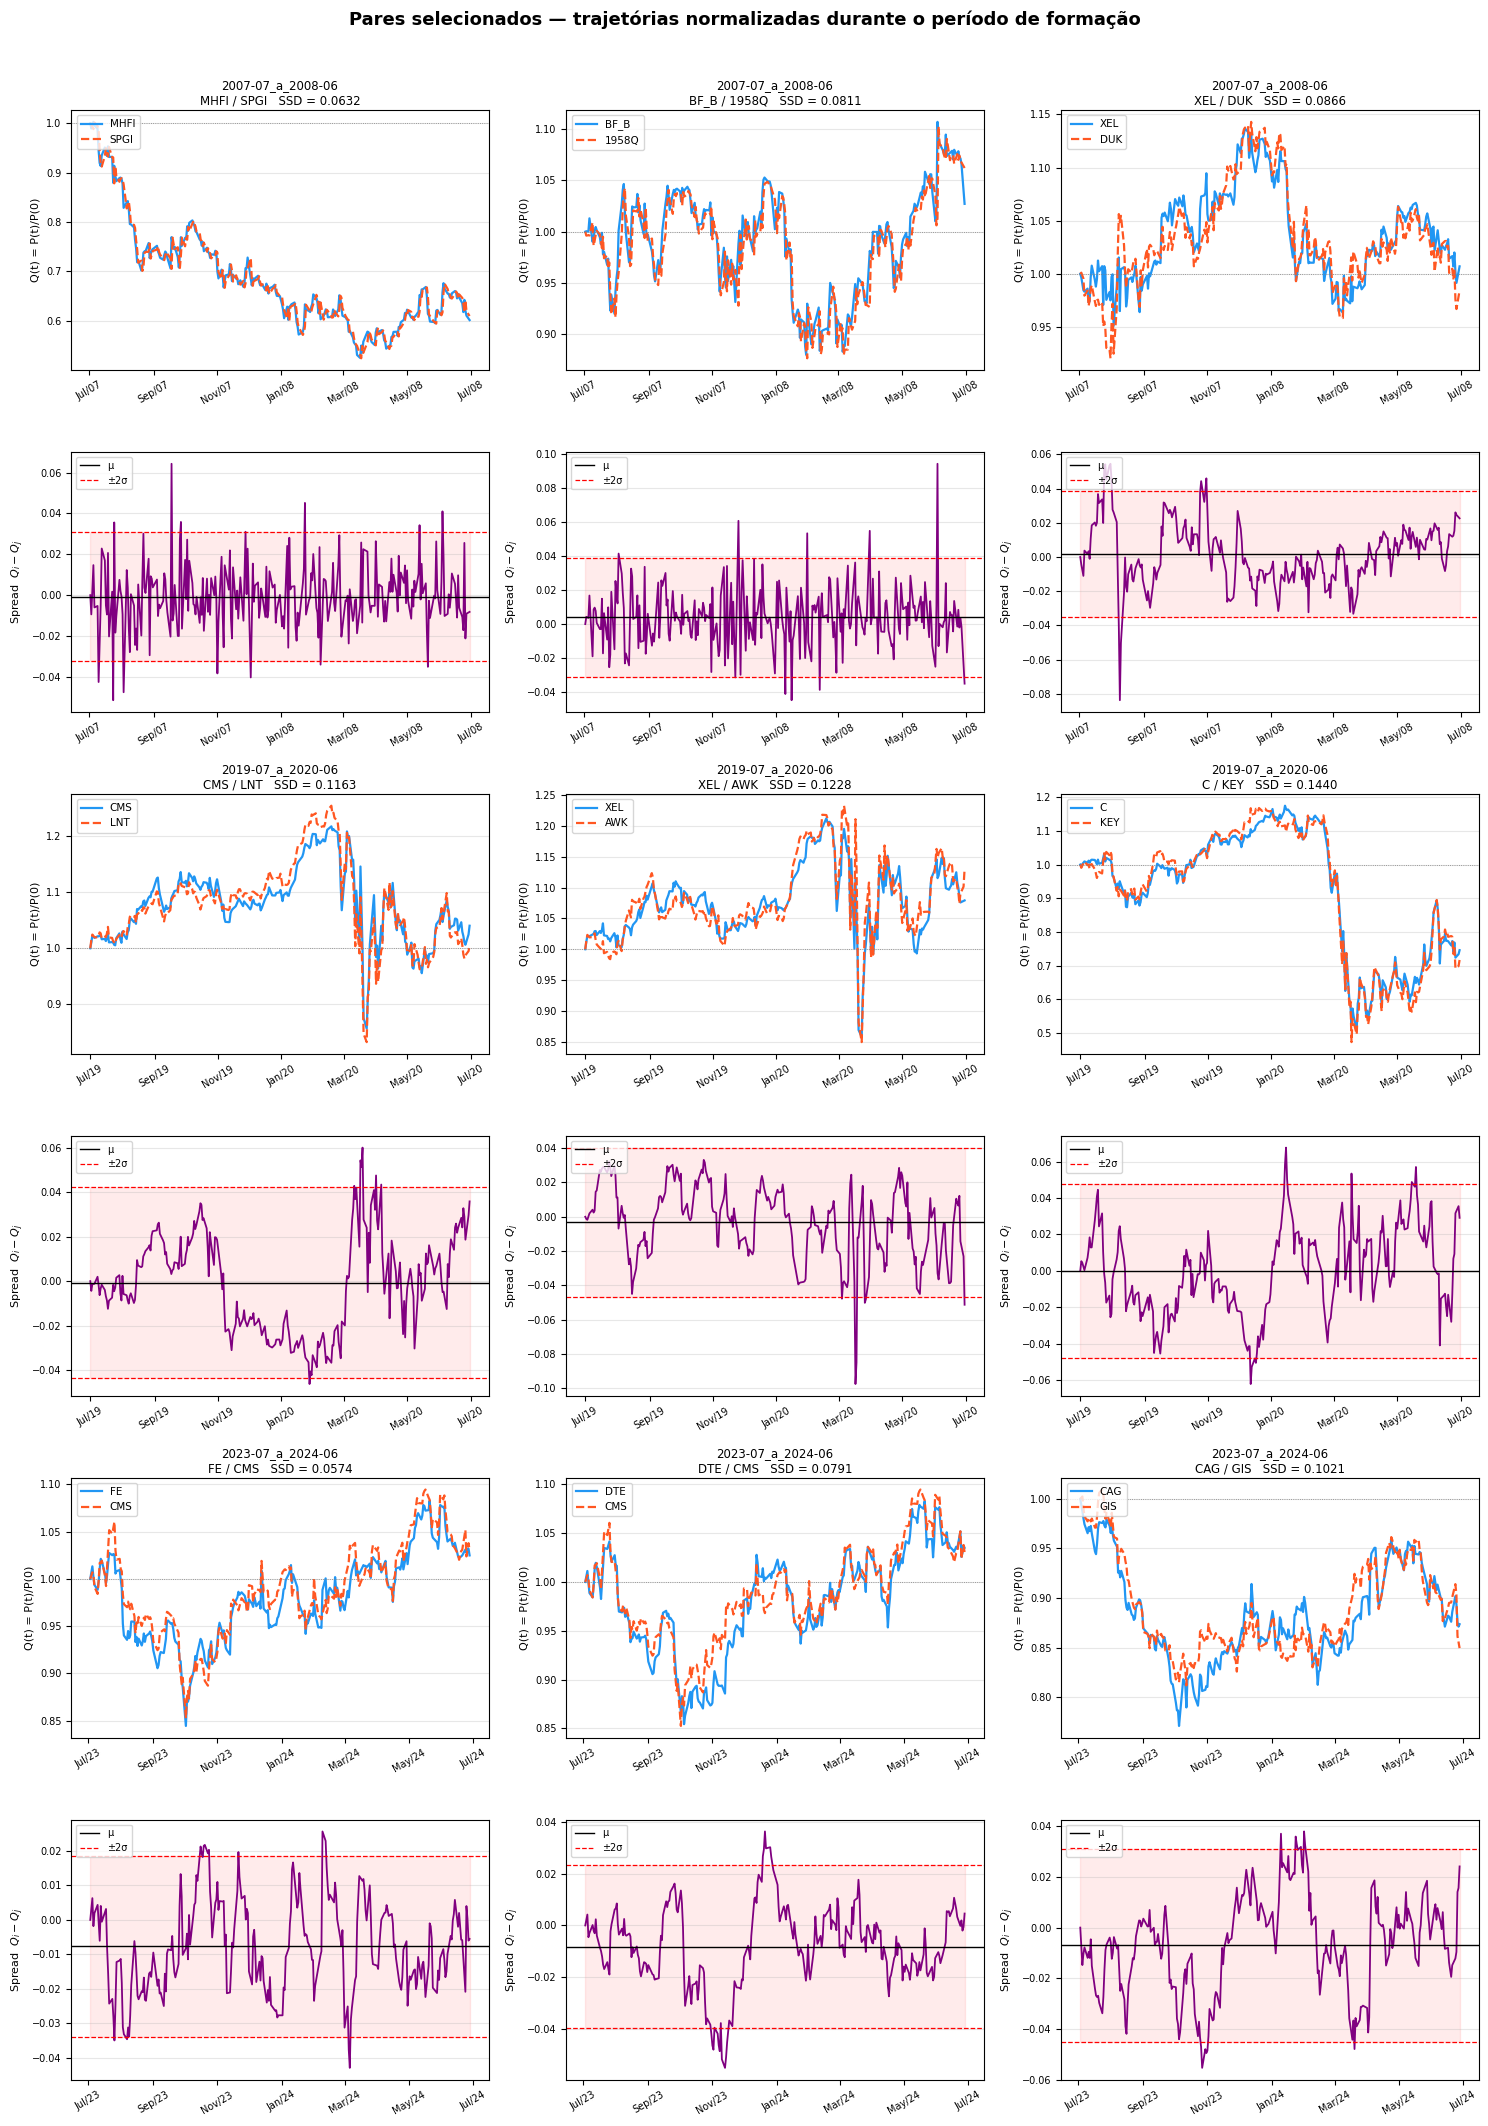

Salvo em: output/pares_visualizacao.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Configuração ──────────────────────────────────────────────────────────────
# Escolhe as janelas pelo mês final da formação (existe em qualquer PASSO_MESES
# que caia nesse mês; caso contrário a janela é simplesmente ignorada).
FORMACAO_FIM_ALVO = ["2008-06", "2020-06", "2024-06"]

JANELAS_ALVO = [
    pares_df.loc[pares_df["formacao_fim"] == alvo, "janela"].iloc[0]
    for alvo in FORMACAO_FIM_ALVO
    if (pares_df["formacao_fim"] == alvo).any()
] or [pares_df["janela"].iloc[0]]

N_PARES     = 3        # quantos pares mostrar por janela
SSD_MIN_VIZ = 1e-5     # ignora pares com SSD ≈ 0 (classes do mesmo papel)

# ── Layout: 2 linhas por janela (preços + spread), N_PARES colunas ────────────
n_rows = len(JANELAS_ALVO) * 2
fig, axes = plt.subplots(n_rows, N_PARES, figsize=(5 * N_PARES, 3.5 * n_rows), squeeze=False)
fig.suptitle(
    "Pares selecionados — trajetórias normalizadas durante o período de formação",
    fontsize=13, fontweight="bold", y=1.01,
)

CORES = ["#2196F3", "#FF5722"]   # azul / laranja para os dois ativos

for bloco, janela_id in enumerate(JANELAS_ALVO):
    row_q = bloco * 2       # linha dos preços normalizados
    row_s = bloco * 2 + 1  # linha do spread

    # Pares da janela, filtrando SSD triviais
    pares_janela = (
        pares_df[
            (pares_df["janela"] == janela_id) &
            (pares_df["ssd"] >= SSD_MIN_VIZ)
        ]
        .head(N_PARES)
    )
    if pares_janela.empty:
        continue

    # Reconstruir Q para essa janela (mesmo recorte em meses usado na formação)
    form_inicio = pd.Period(pares_janela.iloc[0]["formacao_inicio"], freq="M")
    form_fim    = pd.Period(pares_janela.iloc[0]["formacao_fim"],    freq="M")
    mask   = (meses_por_linha >= form_inicio) & (meses_por_linha <= form_fim)
    precos = filtrar_ativos_completos(df.loc[mask, colunas_preco])
    Q      = normalizar_precos(precos)

    for col, (_, par) in enumerate(pares_janela.iterrows()):
        a1, a2 = par["ativo1"], par["ativo2"]

        # Pular se algum ticker não tem dado completo nessa janela
        if a1 not in Q.columns or a2 not in Q.columns:
            for ax in [axes[row_q, col], axes[row_s, col]]:
                ax.axis("off")
            continue

        ax_q = axes[row_q, col]
        ax_s = axes[row_s, col]
        mu, sigma = par["spread_media"], par["spread_desvio"]

        # ── Painel superior: Q_i(t) e Q_j(t) ─────────────────────────────
        ax_q.plot(Q.index, Q[a1], color=CORES[0], lw=1.6, label=a1)
        ax_q.plot(Q.index, Q[a2], color=CORES[1], lw=1.6, ls="--", label=a2)
        ax_q.axhline(1, color="gray", lw=0.6, ls=":")
        ax_q.set_title(
            f"{janela_id}\n{a1} / {a2}   SSD = {par['ssd']:.4f}",
            fontsize=8.5, pad=4,
        )
        ax_q.set_ylabel("Q(t) = P(t)/P(0)", fontsize=8)
        ax_q.legend(fontsize=7.5, loc="upper left")
        ax_q.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
        ax_q.tick_params(axis="x", rotation=30, labelsize=7)
        ax_q.tick_params(axis="y", labelsize=7)
        ax_q.grid(axis="y", alpha=0.3)

        # ── Painel inferior: spread e banda ±2σ ───────────────────────────
        spread = Q[a1] - Q[a2]
        ax_s.plot(spread.index, spread, color="purple", lw=1.3)
        ax_s.axhline(mu,             color="black", lw=1.0, ls="-",  label="μ")
        ax_s.axhline(mu + 2 * sigma, color="red",   lw=0.9, ls="--", label="±2σ")
        ax_s.axhline(mu - 2 * sigma, color="red",   lw=0.9, ls="--")
        ax_s.fill_between(spread.index,
                           mu - 2 * sigma, mu + 2 * sigma,
                           alpha=0.08, color="red")
        ax_s.set_ylabel("Spread  $Q_i - Q_j$", fontsize=8)
        ax_s.legend(fontsize=7, loc="upper left")
        ax_s.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
        ax_s.tick_params(axis="x", rotation=30, labelsize=7)
        ax_s.tick_params(axis="y", labelsize=7)
        ax_s.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("output/pares_visualizacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em: output/pares_visualizacao.png")